In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from itertools import combinations
from scipy.stats import chisquare, entropy, ks_2samp, wasserstein_distance
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import umap.umap_ as umap


In [22]:
real_path = "../../data/data_for_CTGAN/CTGAN_basedata.csv"
syn_path = "../../data/synthetic_result_data/536_synthetic_train_data.csv"
df_real = pd.read_csv(real_path)
df_syn = pd.read_csv(syn_path)

# Statistical Analysis

## Statistical Similarity Score
Calculates statistical similarity subscores between original and synthetic datasets for each feature using various statistical metrics (e.g., mean, variance, KS-test, Wasserstein distance, KL divergence), and combines them into an overall similarity score (SSS).

In [23]:
def compute_subscores(original: pd.DataFrame, synthetic: pd.DataFrame, alpha_kl=1.0, mmd_gamma=1.0, weights=None):
    """
    Parameters:
    - original: The original dataset (as a pandas DataFrame).
    - synthetic: The synthetic dataset to compare (as a pandas DataFrame).
    - alpha_kl: Scaling factor for KL divergence.
    - mmd_gamma: Kernel width parameter for the MMD metric.
    - weights: Optional dictionary specifying weights for each submetric.

    Returns:
    - Dictionary with per-feature subscores and the overall Statistical Similarity Score (SSS).
    """

    def compute_mmd(x, y, gamma):
        """Compute the unbiased Maximum Mean Discrepancy (MMD) using a Gaussian (RBF) kernel."""
        X = x.values.flatten()
        Y = y.values.flatten()

        # Kernel matrices
        Kxx = np.exp(-gamma * (X[:, None] - X[None, :])**2)
        Kyy = np.exp(-gamma * (Y[:, None] - Y[None, :])**2)
        Kxy = np.exp(-gamma * (X[:, None] - Y[None, :])**2)

        # Sample sizes
        n, m = len(X), len(Y)

        # Unbiased estimate of MMD^2
        mmd2 = (
            (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.sum() / (n * m)
        )
        return np.sqrt(max(mmd2, 0))

    # Define the names of metrics used for the similarity score
    metric_names = ['mean','median','variance','ks','chi2','wasserstein','mmd','kl','coverage']

    # If no custom weights are provided, use equal weighting
    if weights is None:
        weights = {name: 1/len(metric_names) for name in metric_names}

    results = {}         # To store subscores per feature
    feature_scores = []  # To store the final score per feature

    # Loop through each column (feature) of the original DataFrame
    for col in original.columns:
        o = original[col]
        s = synthetic[col]
        subscores = {}

        if pd.api.types.is_numeric_dtype(o):  # Numerical features
            R = o.max() - o.min()

            # Mean difference normalized by range
            delta_mean = abs(o.mean() - s.mean())
            subscores['mean'] = max(0, 1 - delta_mean / R) if R > 0 else 1.0

            # Median difference normalized by range
            delta_median = abs(o.median() - s.median())
            subscores['median'] = max(0, 1 - delta_median / R) if R > 0 else 1.0

            # Variance difference normalized by max variance
            V = max(o.var(), s.var())
            delta_var = abs(o.var() - s.var())
            subscores['variance'] = max(0, 1 - delta_var / V) if V > 0 else 1.0

            # Kolmogorov-Smirnov test p-value
            subscores['ks'] = ks_2samp(o, s).pvalue

            # Wasserstein distance transformed to a similarity score
            w_dist = wasserstein_distance(o, s)
            subscores['wasserstein'] = 1 / (1 + w_dist)

            # Maximum Mean Discrepancy similarity
            mmd_val = compute_mmd(o, s, mmd_gamma)
            subscores['mmd'] = 1 / (1 + mmd_val)

            # KL divergence between histograms (smoothed with epsilon)
            bins = min(50, max(o.nunique(), s.nunique()))
            p_hist, _ = np.histogram(o, bins=bins, density=True)
            q_hist, _ = np.histogram(s, bins=bins, density=True)
            p_hist += 1e-8
            q_hist += 1e-8
            kl_div = entropy(p_hist, q_hist)
            subscores['kl'] = np.exp(-alpha_kl * kl_div)  # Transform to similarity

            # Category coverage: proportion of unique values preserved
            cov = len(np.intersect1d(o.unique(), s.unique())) / o.nunique() if o.nunique() > 0 else 1.0
            subscores['coverage'] = cov

        else:  # Categorical features
            real_counts = o.value_counts().sort_index()
            syn_counts = s.value_counts().reindex(real_counts.index, fill_value=0)

            # Chi-squared test p-value
            stat, p_value = chisquare(f_obs=syn_counts, f_exp=real_counts)
            subscores['chi2'] = p_value

            # Category coverage
            cov = len(set(o.unique()) & set(s.unique())) / len(o.unique()) if o.nunique() > 0 else 1.0
            subscores['coverage'] = cov

        # Filter available metrics and normalize weights
        available_metrics = [k for k in subscores if k in weights]
        total_weight = sum(weights[k] for k in available_metrics)

        # Weighted average score for the feature
        score = sum(weights[k] * subscores[k] for k in available_metrics) / total_weight if total_weight > 0 else 0
        results[col] = {'subscores': subscores, 'feature_score': score}
        feature_scores.append(score)

    # Final overall SSS is the mean of per-feature scores
    overall_sss = float(np.mean(feature_scores))
    return {'per_feature': results, 'SSS': overall_sss}


In [24]:
# Define custom weights for each metric to reflect their importance in the final score
custom_weights = {
    'mean': 0.05,         # Small weight to mean difference
    'median': 0.05,       # Small weight to median difference
    'variance': 0.05,     # Small weight to variance difference
    'ks': 0.1,            # Moderate weight to KS-test p-value
    'chi2': 0.1,          # Moderate weight to Chi-squared test p-value
    'wasserstein': 0.2,   # High weight to Wasserstein distance similarity
    'mmd': 0.2,           # High weight to Maximum Mean Discrepancy similarity
    'kl': 0.2,            # High weight to KL divergence similarity
    'coverage': 0.05      # Small weight to category/uniqueness overlap
}

# Compute subscores and the overall SSS using the custom weights
result = compute_subscores(df_real, df_syn, weights=custom_weights)

# Print the overall Statistical Similarity Score
print("Statistical Similarity Score (SSS):", result['SSS'])

# Print detailed subscores and final feature score for each feature
for feature, data in result['per_feature'].items():
    print(f"\nFeature: {feature}")
    print(" Subscores:", data['subscores'])         # Dictionary of individual metric scores
    print(" Feature score:", data['feature_score'])  # Weighted average score for this feature


Statistical Similarity Score (SSS): 0.781359304632074

Feature: geschlecht
 Subscores: {'chi2': np.float64(6.612374506157755e-29), 'coverage': 1.0}
 Feature score: 0.3333333333333333

Feature: alter
 Subscores: {'chi2': np.float64(6.59652050293519e-14), 'coverage': 0.9333333333333333}
 Feature score: 0.3111111111111551

Feature: bundesland
 Subscores: {'chi2': np.float64(4.792397314701809e-05), 'coverage': 0.46153846153846156}
 Feature score: 0.15387810316158518

Feature: beruf
 Subscores: {'chi2': np.float64(1.3227155700653558e-38), 'coverage': 0.8888888888888888}
 Feature score: 0.2962962962962963

Feature: konsumhaeufigkeit
 Subscores: {'chi2': np.float64(0.001333341076843179), 'coverage': 1.0}
 Feature score: 0.3342222273845621

Feature: situation_freunde_familie
 Subscores: {'mean': np.float64(0.9365671641791047), 'median': np.float64(0.5), 'variance': np.float64(1.0), 'ks': np.float64(0.0003530494711383479), 'wasserstein': np.float64(0.8874172185430463), 'mmd': np.float64(0.87867

## Visual Analysis

### Distribution of each features
visualizes the distributions of each numerical feature from real and synthetic datasets by plotting their density curves side-by-side, highlighting differences in distributions and means using kernel density estimation (KDE) plots.


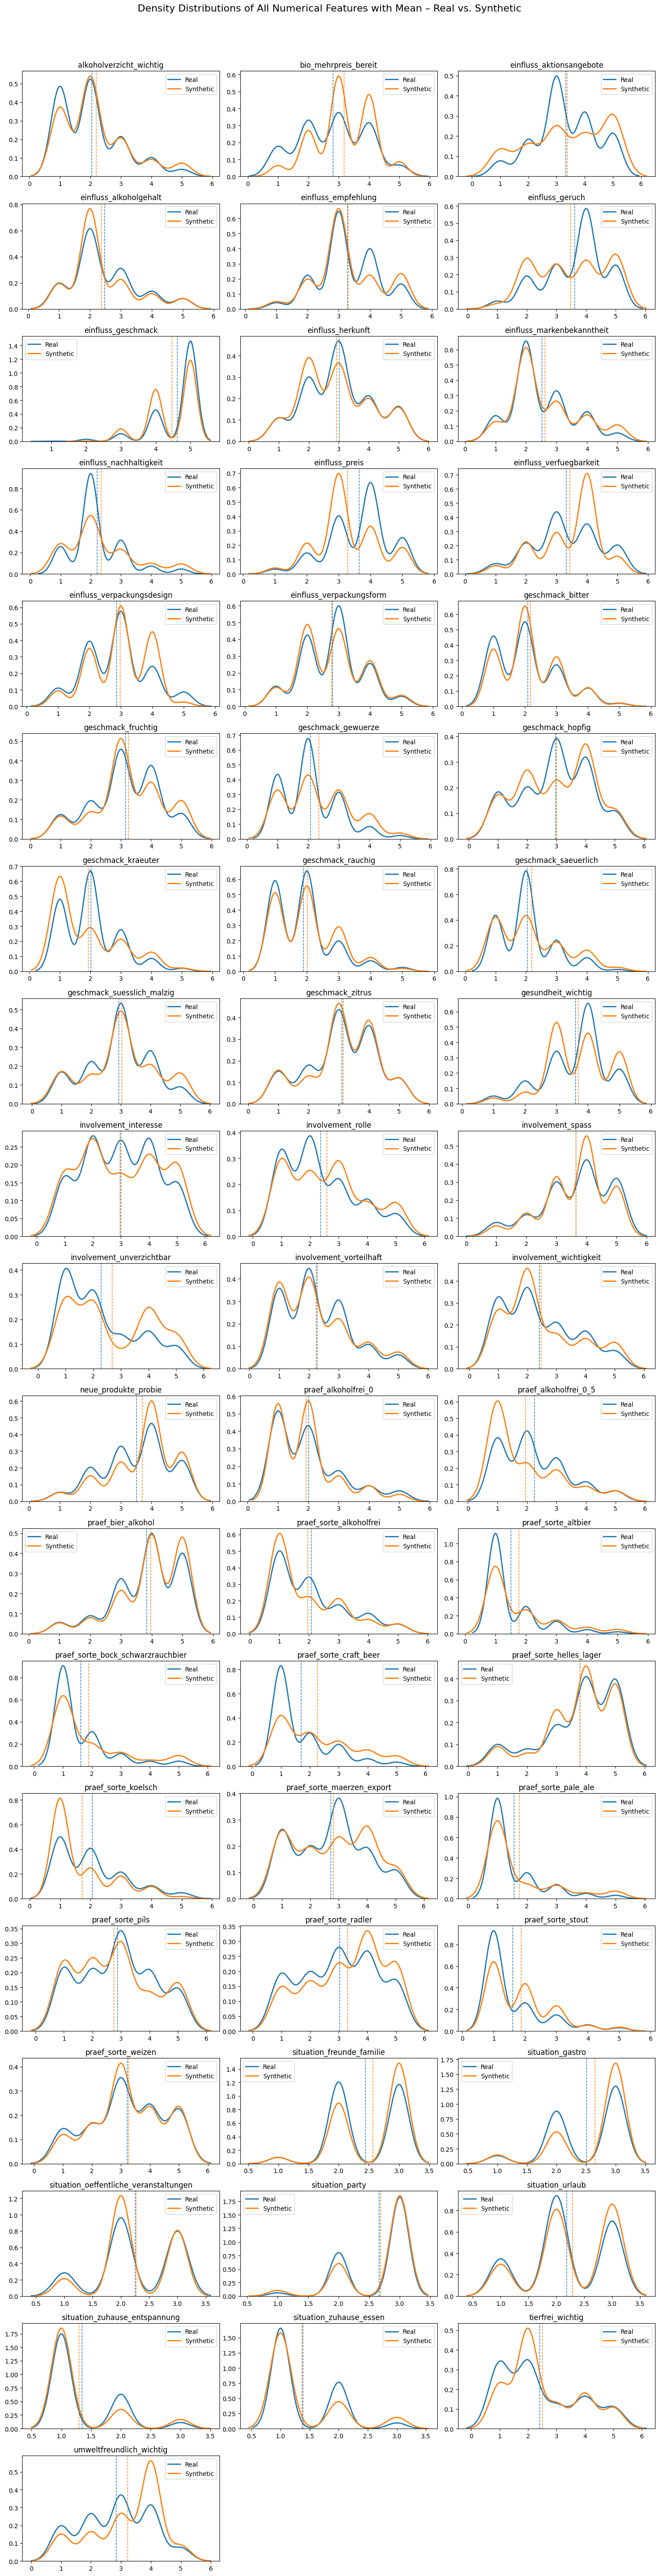

In [25]:
# Select only numerical columns from both real and synthetic datasets
df_real_num = df_real.select_dtypes(include='number')
df_syn_num = df_syn.select_dtypes(include='number')

# Ensure that both datasets contain the same set of numerical columns
common_cols = list(set(df_real_num.columns) & set(df_syn_num.columns))
df_real_num = df_real_num[common_cols]
df_syn_num = df_syn_num[common_cols]
n_cols = 3  
n_rows = (len(common_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(n_cols * 5, n_rows * 3))

# Plot KDE for each numerical column
for i, col in enumerate(sorted(common_cols)):
    plt.subplot(n_rows, n_cols, i + 1) 
    sns.kdeplot(df_real_num[col], label="Real", color="tab:blue", linewidth=2)
    sns.kdeplot(df_syn_num[col], label="Synthetic", color="tab:orange", linewidth=2)
    plt.axvline(df_real_num[col].mean(), color="tab:blue", linestyle="--", linewidth=1)
    plt.axvline(df_syn_num[col].mean(), color="tab:orange", linestyle="--", linewidth=1)
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend()

plt.tight_layout()
plt.suptitle("Density Distributions of All Numerical Features with Mean – Real vs. Synthetic", 
             y=1.02, fontsize=16)

# Show the plot
plt.show()


### Feature - Situation
compares the average ratings and variability of different consumption-related situations between real and synthetic datasets using a grouped bar chart with error bars.

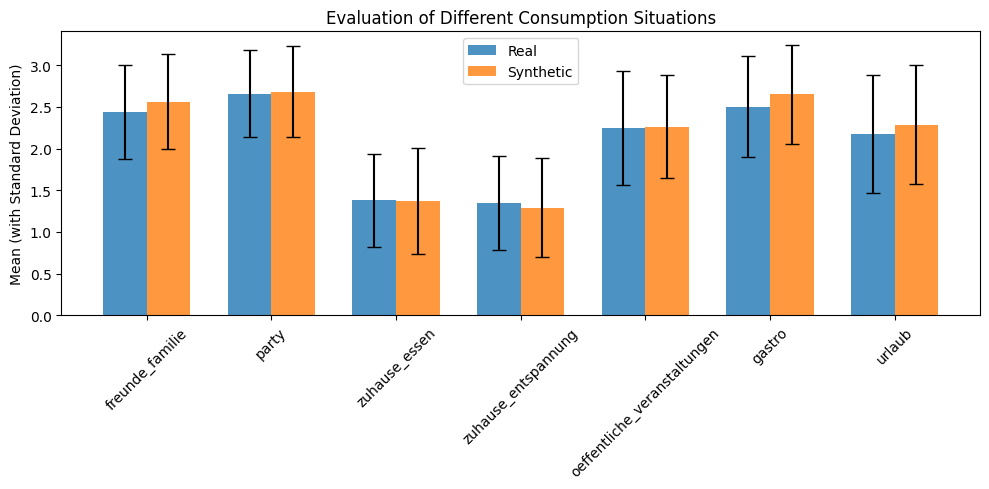

In [26]:
situation_features = [
    "situation_freunde_familie",          # friends & family
    "situation_party",                    # party
    "situation_zuhause_essen",            # eating at home
    "situation_zuhause_entspannung",      # relaxing at home
    "situation_oeffentliche_veranstaltungen", # public events
    "situation_gastro",                   # gastronomy (restaurants, cafés)
    "situation_urlaub"                    # vacation
]

# Convert to numeric, if not already
df_real[situation_features] = df_real[situation_features].apply(pd.to_numeric, errors='coerce')
df_syn[situation_features] = df_syn[situation_features].apply(pd.to_numeric, errors='coerce')

# Calculate means & standard deviations
mean_real = df_real[situation_features].mean()
std_real = df_real[situation_features].std()
mean_syn = df_syn[situation_features].mean()
std_syn = df_syn[situation_features].std()

# Prepare plot
x = range(len(situation_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetic', alpha=0.8)

plt.xticks(x, [s.replace("situation_", "") for s in situation_features], rotation=45)
plt.ylabel("Mean (with Standard Deviation)")
plt.title("Evaluation of Different Consumption Situations")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Involvement
visualizes and compares the average values and variability of user involvement features between real and synthetic datasets using a grouped bar chart with error bars.

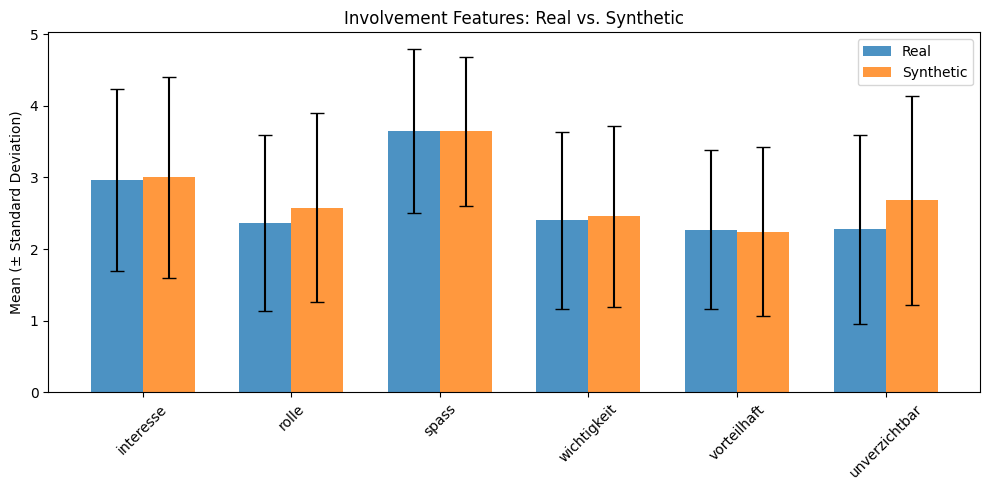

In [27]:
# List of involvement-related features
involvement_features = [
    "involvement_interesse",         # interest
    "involvement_rolle",             # role
    "involvement_spass",             # fun
    "involvement_wichtigkeit",       # importance
    "involvement_vorteilhaft",       # advantageous
    "involvement_unverzichtbar"      # indispensable
]

# Ensure the involvement features are numeric (convert if necessary)
df_real[involvement_features] = df_real[involvement_features].apply(pd.to_numeric, errors='coerce')
df_syn[involvement_features] = df_syn[involvement_features].apply(pd.to_numeric, errors='coerce')

# Calculate mean and standard deviation for both datasets
mean_real = df_real[involvement_features].mean()
std_real = df_real[involvement_features].std()
mean_syn = df_syn[involvement_features].mean()
std_syn = df_syn[involvement_features].std()

# Prepare bar plot
x = range(len(involvement_features))
width = 0.35

plt.figure(figsize=(10, 5))

# Plot bars 
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetic', alpha=0.8)

plt.xticks(x, [s.replace("involvement_", "") for s in involvement_features], rotation=45)
plt.ylabel("Mean (± Standard Deviation)")
plt.title("Involvement Features: Real vs. Synthetic")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Influences
compares the average responses and variability for attitudes related to health, environmental awareness, and product preferences between real and synthetic datasets using a grouped bar chart with error bars.

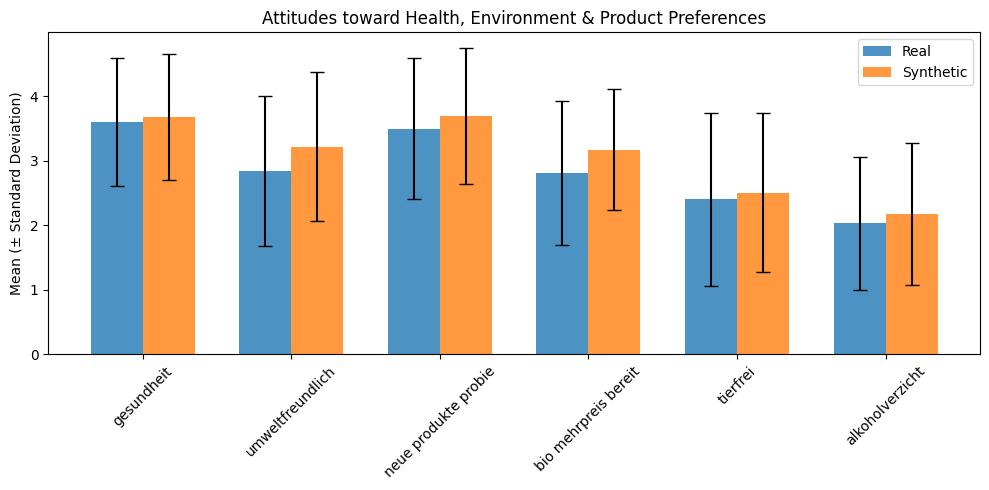

In [28]:
# Feature list
bewertung_features = [
    "gesundheit_wichtig",            # health important
    "umweltfreundlich_wichtig",      # environmentally friendly important
    "neue_produkte_probie",          # try new products
    "bio_mehrpreis_bereit",          # willing to pay more for organic
    "tierfrei_wichtig",              # animal-free important
    "alkoholverzicht_wichtig"        # alcohol abstinence important
]

# Convert to numeric (if necessary)
df_real[bewertung_features] = df_real[bewertung_features].apply(pd.to_numeric, errors='coerce')
df_syn[bewertung_features] = df_syn[bewertung_features].apply(pd.to_numeric, errors='coerce')

# Calculate means and standard deviations
mean_real = df_real[bewertung_features].mean()
std_real = df_real[bewertung_features].std()
mean_syn = df_syn[bewertung_features].mean()
std_syn = df_syn[bewertung_features].std()

# Plot
x = range(len(bewertung_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetic', alpha=0.8)

plt.xticks(x, [f.replace("_wichtig", "").replace("_", " ") for f in bewertung_features], rotation=45)
plt.ylabel("Mean (± Standard Deviation)")
plt.title("Attitudes toward Health, Environment & Product Preferences")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Buying Decision
visualizes and compares how various product-related influence factors (e.g. taste, price, sustainability) impact purchasing decisions in real vs. synthetic datasets using a grouped bar chart with error bars.

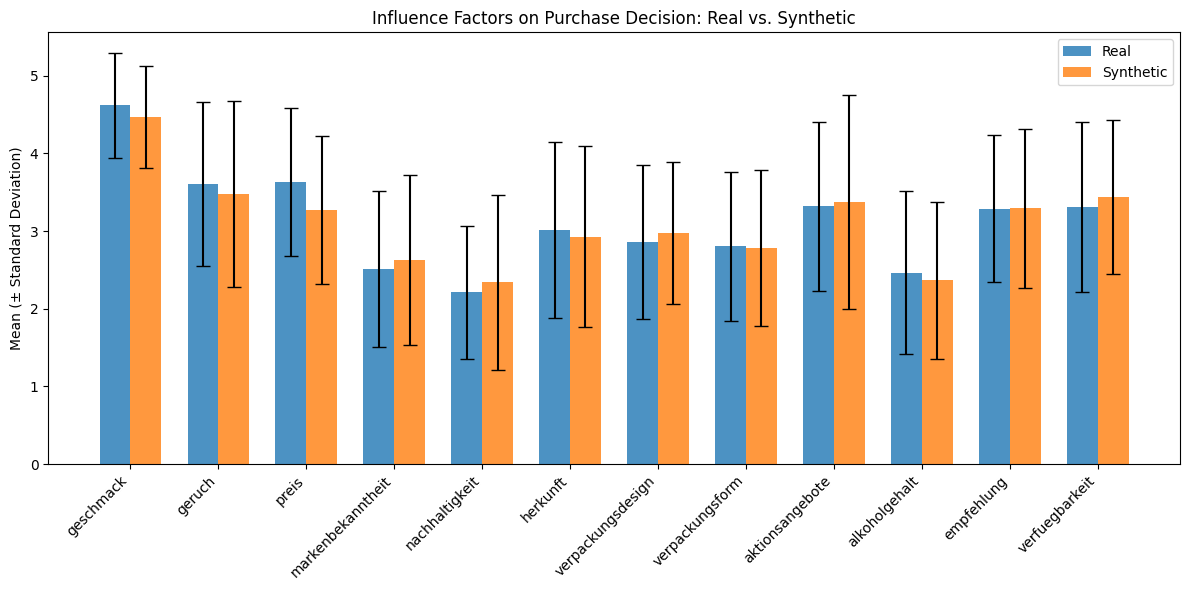

In [29]:
# List of influence-related features
einfluss_features = [
    "einfluss_geschmack",             # taste
    "einfluss_geruch",                # smell
    "einfluss_preis",                 # price
    "einfluss_markenbekanntheit",     # brand awareness
    "einfluss_nachhaltigkeit",        # sustainability
    "einfluss_herkunft",              # origin
    "einfluss_verpackungsdesign",     # packaging design
    "einfluss_verpackungsform",       # packaging shape
    "einfluss_aktionsangebote",       # promotional offers
    "einfluss_alkoholgehalt",         # alcohol content
    "einfluss_empfehlung",            # recommendation
    "einfluss_verfuegbarkeit"         # availability
]

# Ensure all values are numeric
df_real[einfluss_features] = df_real[einfluss_features].apply(pd.to_numeric, errors='coerce')
df_syn[einfluss_features] = df_syn[einfluss_features].apply(pd.to_numeric, errors='coerce')

# Calculate mean and standard deviation
mean_real = df_real[einfluss_features].mean()
std_real = df_real[einfluss_features].std()
mean_syn = df_syn[einfluss_features].mean()
std_syn = df_syn[einfluss_features].std()

# Prepare plot
x = range(len(einfluss_features))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetic', alpha=0.8)

# Format axis labels for readability
xtick_labels = [f.replace("einfluss_", "").replace("_", " ") for f in einfluss_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mean (± Standard Deviation)")
plt.title("Influence Factors on Purchase Decision: Real vs. Synthetic")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Preferences
compares the mean and variability of various beer preferences (e.g., types and alcohol levels) between real and synthetic datasets using a grouped bar chart with error bars.

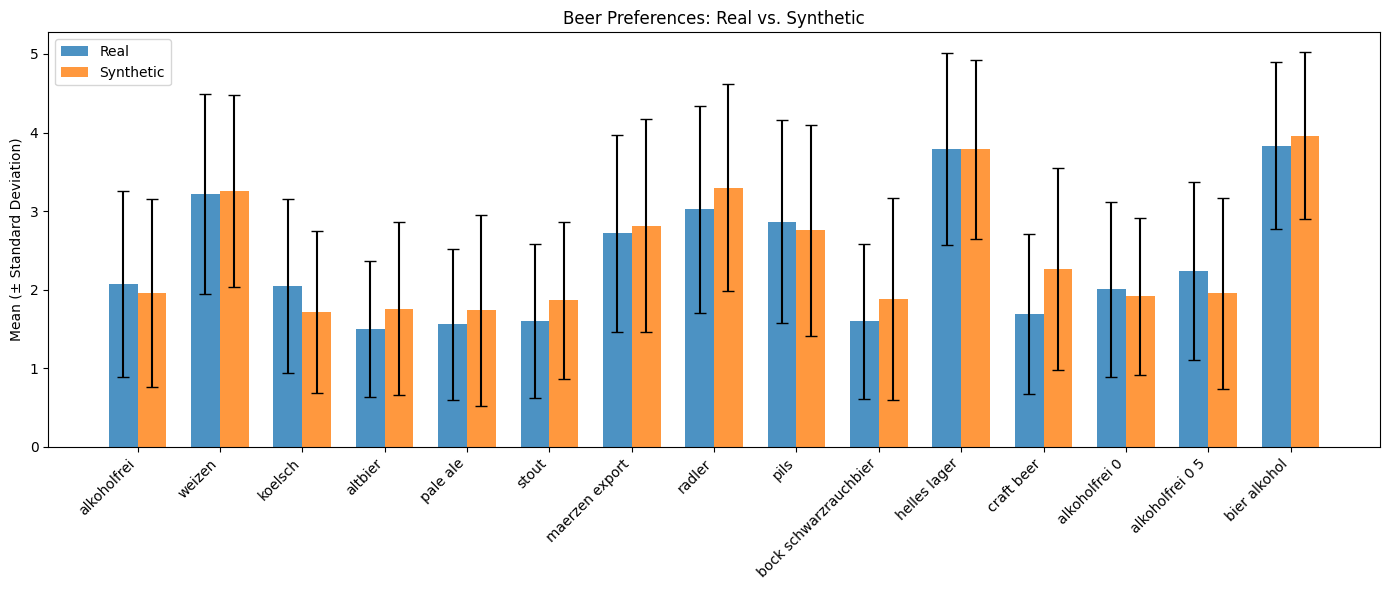

In [30]:
# Feature list for beer preferences
bierpraef_features = [
    "praef_sorte_alkoholfrei",              # alcohol-free
    "praef_sorte_weizen",                   # wheat beer
    "praef_sorte_koelsch",                  # Kölsch
    "praef_sorte_altbier",                  # Altbier
    "praef_sorte_pale_ale",                 # pale ale
    "praef_sorte_stout",                    # stout
    "praef_sorte_maerzen_export",           # Märzen/export
    "praef_sorte_radler",                   # Radler
    "praef_sorte_pils",                     # pilsner
    "praef_sorte_bock_schwarzrauchbier",    # bock, black, smoked beer
    "praef_sorte_helles_lager",             # light lager
    "praef_sorte_craft_beer",               # craft beer
    "praef_alkoholfrei_0",                  # alcohol-free 0.0%
    "praef_alkoholfrei_0_5",                # alcohol-free 0.5%
    "praef_bier_alkohol"                    # general alcohol preference in beer
]

# Ensure values are numeric
df_real[bierpraef_features] = df_real[bierpraef_features].apply(pd.to_numeric, errors='coerce')
df_syn[bierpraef_features] = df_syn[bierpraef_features].apply(pd.to_numeric, errors='coerce')

# Calculate means and standard deviations
mean_real = df_real[bierpraef_features].mean()
std_real = df_real[bierpraef_features].std()
mean_syn = df_syn[bierpraef_features].mean()
std_syn = df_syn[bierpraef_features].std()

# Plot
x = range(len(bierpraef_features))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=4, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=4, label='Synthetic', alpha=0.8)

# Format x-axis labels
xtick_labels = [f.replace("praef_sorte_", "").replace("praef_", "").replace("_", " ") for f in bierpraef_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mean (± Standard Deviation)")
plt.title("Beer Preferences: Real vs. Synthetic")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Taste Preferences
compares average ratings and variability of different taste preferences (e.g., smoky, fruity, bitter) between real and synthetic datasets using a grouped bar chart with error bars.

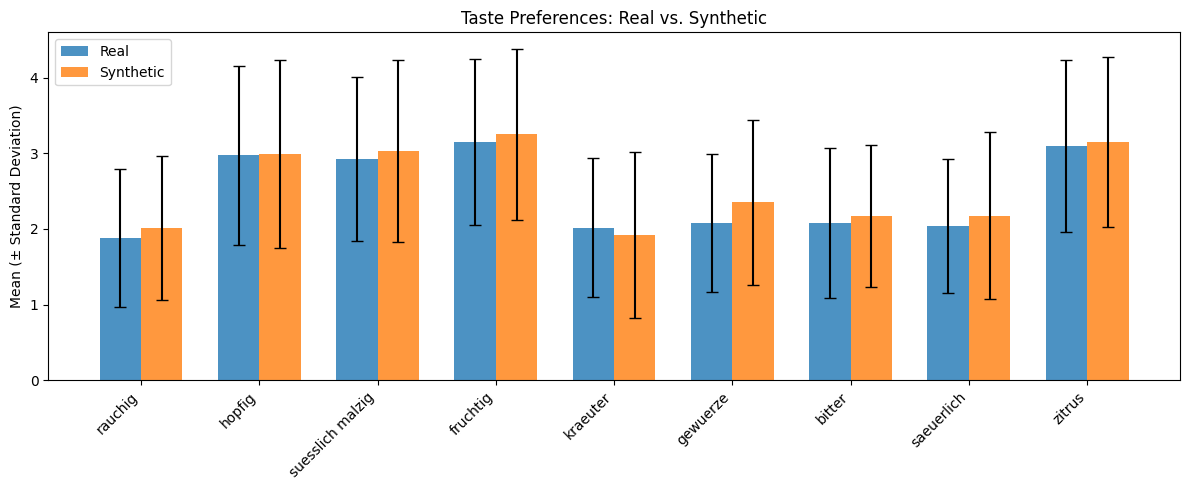

In [31]:
# List of taste-related features
geschmack_features = [
    "geschmack_rauchig",             # smoky
    "geschmack_hopfig",              # hoppy
    "geschmack_suesslich_malzig",    # sweet/malty
    "geschmack_fruchtig",            # fruity
    "geschmack_kraeuter",            # herbal
    "geschmack_gewuerze",            # spicy
    "geschmack_bitter",              # bitter
    "geschmack_saeuerlich",          # sour
    "geschmack_zitrus"               # citrus
]

# Ensure values are numeric
df_real[geschmack_features] = df_real[geschmack_features].apply(pd.to_numeric, errors='coerce')
df_syn[geschmack_features] = df_syn[geschmack_features].apply(pd.to_numeric, errors='coerce')

# Calculate mean and standard deviation
mean_real = df_real[geschmack_features].mean()
std_real = df_real[geschmack_features].std()
mean_syn = df_syn[geschmack_features].mean()
std_syn = df_syn[geschmack_features].std()

# Plot
x = range(len(geschmack_features))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=4, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=4, label='Synthetic', alpha=0.8)

# Clean axis labels
xtick_labels = [f.replace("geschmack_", "").replace("_", " ") for f in geschmack_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mean (± Standard Deviation)")
plt.title("Taste Preferences: Real vs. Synthetic")
plt.legend()
plt.tight_layout()
plt.show()


### Correlation Matrix
calculates and visualizes the correlation structures of all numerical features in the real and synthetic datasets side by side using heatmaps, allowing a visual comparison of their internal relationships.

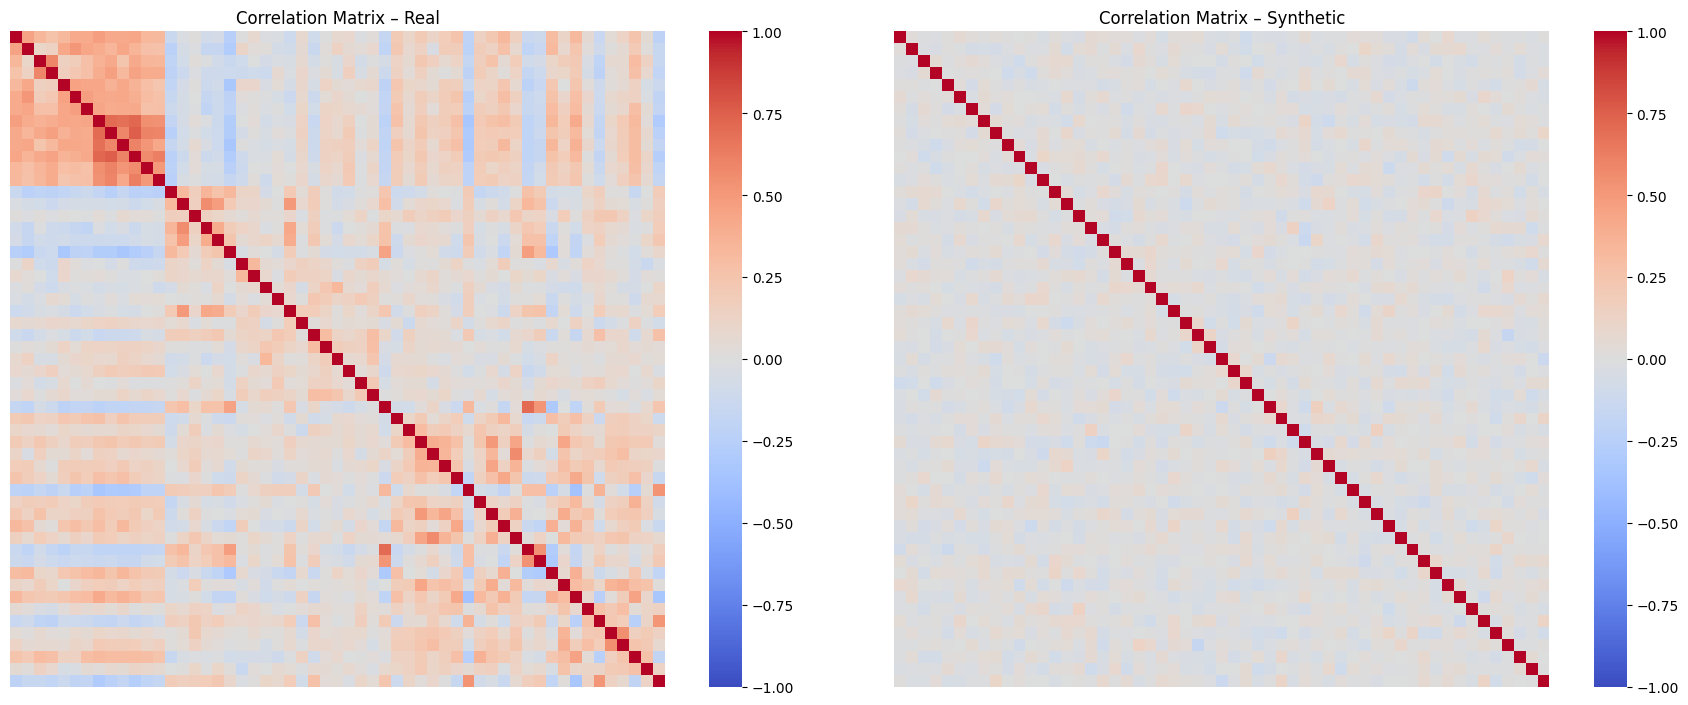

In [32]:
# Automatically select numerical columns
df_real_num = df_real.select_dtypes(include='number')
df_syn_num = df_syn.select_dtypes(include='number')

# Compute correlation matrices
corr_real = df_real_num.corr()
corr_syn = df_syn_num.corr()

# Plot without feature names
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_real, ax=axes[0], cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar=True,
            xticklabels=False, yticklabels=False, square=True)
axes[0].set_title("Correlation Matrix – Real")

sns.heatmap(corr_syn, ax=axes[1], cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar=True,
            xticklabels=False, yticklabels=False, square=True)
axes[1].set_title("Correlation Matrix – Synthetic")

plt.tight_layout()
plt.show()


# Structural Consistency

## Structural Consistency Score
compares the structural characteristics of an original and synthetic dataset and returns a universal similarity score between 0 and 1, where 1 indicates high structural similarity.

In [33]:
def compute_structural_similarity_score(original: pd.DataFrame,
                                        synthetic: pd.DataFrame,
                                        eps=0.5,
                                        min_samples=5,
                                        weights=None):
    """
    Computes a universal structural similarity score ∈ [0,1], where 1 is best.
    Integrates:
      - Cluster Purity (KMeans & DBSCAN)
      - Adjusted Rand Index (KMeans & DBSCAN)
      - Cosine Similarity of global mean feature vectors
    Each subscore ∈ [0,1]; final score is the average.
    """
    # Preprocessing: one-hot encode categorical + standardize numeric
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)
    
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))
    
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler().fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)
    
    # Feature matrices
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels = np.concatenate([np.zeros(len(X_orig)), np.ones(len(X_syn))])
    X_joint = np.vstack([X_orig, X_syn])
    
    # 1. Cluster Purity Subscores
    def purity_subscore(cl_labels):
        subs = []
        for c in np.unique(cl_labels):
            mask = (cl_labels == c)
            counts = np.bincount(labels[mask].astype(int), minlength=2)
            if counts.sum() == 0: continue
            purity = counts.max() / counts.sum()
            # Map purity 0.5->1.0, purity 1.0->0.0
            subs.append(max(0, 1 - abs(purity - 0.5) / 0.5))
        return np.mean(subs) if subs else 0.0
    
    km_labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_joint)
    db_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_joint)
    s_purity_km = purity_subscore(km_labels)
    s_purity_db = purity_subscore(db_labels)
    
    # 2. ARI Subscores
    s_ari_km = 1 - abs(adjusted_rand_score(labels, km_labels))
    s_ari_db = 1 - abs(adjusted_rand_score(labels, db_labels))
    
    # 3. Cosine Similarity Subscore
    vec_orig = X_orig.mean(axis=0).reshape(1, -1)
    vec_syn  = X_syn.mean(axis=0).reshape(1, -1)
    cos_val = cosine_similarity(vec_orig, vec_syn)[0, 0]
    s_cos = (cos_val + 1) / 2  
    
    # Default equal weights across 5 subscores
    if weights is None:
        weights = {
            'purity_km': 0.15,
            'purity_db': 0.15,
            'ARI_km':    0.15,
            'ARI_db':    0.15,
            'cosine':    0.40
        } 
    
    # Combine
    structural_score = (
        weights['purity_km'] * s_purity_km +
        weights['purity_db'] * s_purity_db +
        weights['ARI_km']    * s_ari_km +
        weights['ARI_db']    * s_ari_db +
        weights['cosine']    * s_cos
    )
    
    return round(float(structural_score), 4)



In [34]:

sim_score = compute_structural_similarity_score(df_real, df_syn)
print("Structure Consistency Score:", sim_score)

Structure Consistency Score: 0.8984


## Visual Analysis

### PCA
performs Principal Component Analysis (PCA) on the numerical features of real and synthetic datasets to reduce them to two dimensions and visualizes their structure side-by-side in scatter plots, using the same axis scaling for comparison.

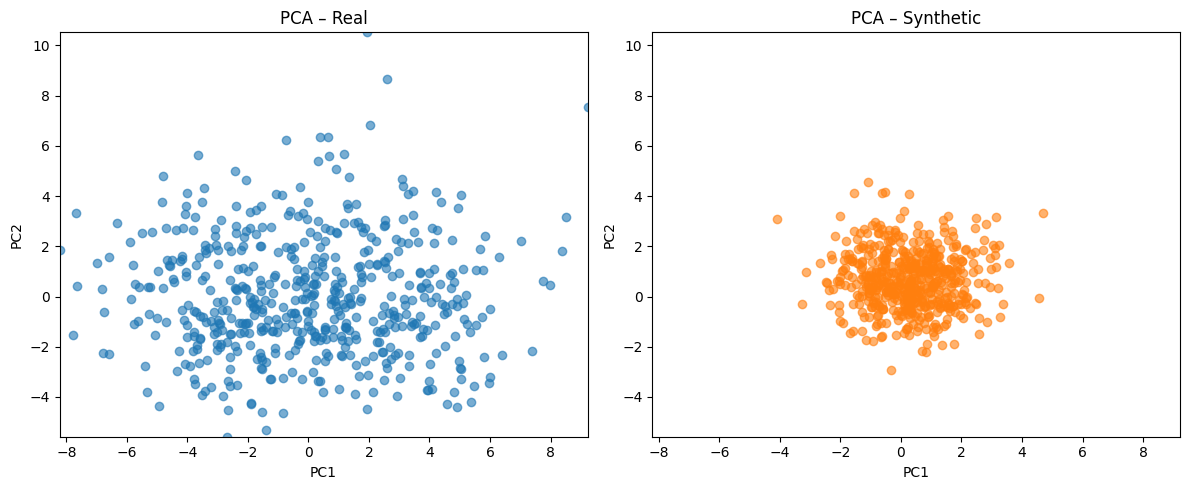

In [35]:
# Extract numerical data and find common columns
df_real_num = df_real.select_dtypes(include='number').dropna(axis=1)
df_syn_num = df_syn.select_dtypes(include='number').dropna(axis=1)

common_cols = list(set(df_real_num.columns) & set(df_syn_num.columns))
df_real_num = df_real_num[common_cols]
df_syn_num = df_syn_num[common_cols]

# PCA: fit on real data, transform both datasets
pca = PCA(n_components=2)
real_pca = pca.fit_transform(df_real_num)
syn_pca = pca.transform(df_syn_num)

# Visualization: side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("PCA – Real")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(syn_pca[:, 0], syn_pca[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("PCA – Synthetic")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# Use the same axis limits for both plots
x_min = min(real_pca[:, 0].min(), syn_pca[:, 0].min())
x_max = max(real_pca[:, 0].max(), syn_pca[:, 0].max())
y_min = min(real_pca[:, 1].min(), syn_pca[:, 1].min())
y_max = max(real_pca[:, 1].max(), syn_pca[:, 1].max())

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


### t-SNE
uses t-SNE to reduce the dimensionality of real and synthetic datasets to two components and visualizes their structures in side-by-side scatter plots with shared axis scaling for better comparison.

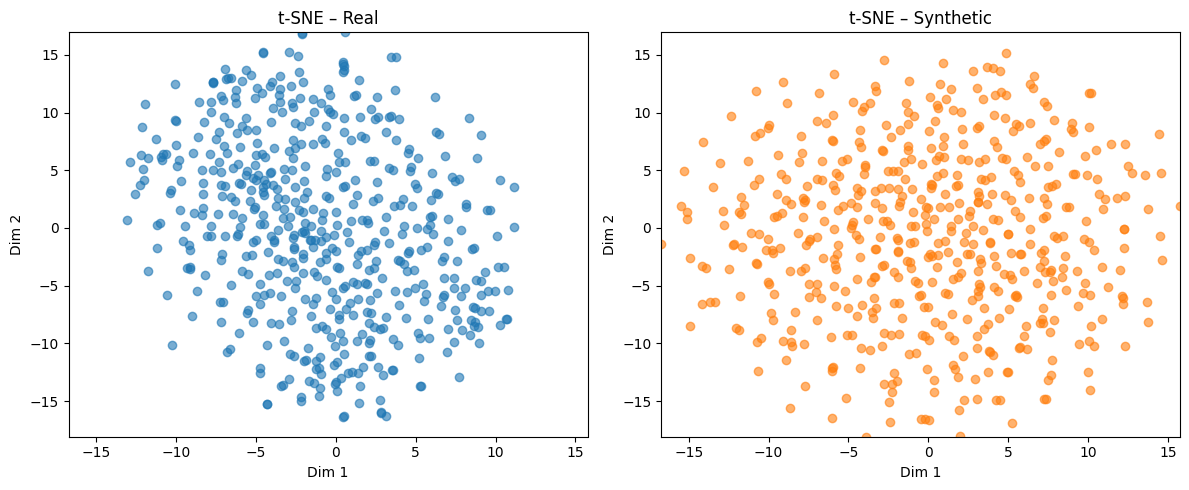

In [36]:
# t-SNE for real and synthetic data
tsne_real = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
real_tsne = tsne_real.fit_transform(df_real_num)

tsne_syn = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
syn_tsne = tsne_syn.fit_transform(df_syn_num)

# Calculate common axis limits
x_min = min(real_tsne[:, 0].min(), syn_tsne[:, 0].min())
x_max = max(real_tsne[:, 0].max(), syn_tsne[:, 0].max())
y_min = min(real_tsne[:, 1].min(), syn_tsne[:, 1].min())
y_max = max(real_tsne[:, 1].max(), syn_tsne[:, 1].max())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_tsne[:, 0], real_tsne[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("t-SNE – Real")
axes[0].set_xlabel("Dim 1")
axes[0].set_ylabel("Dim 2")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

axes[1].scatter(syn_tsne[:, 0], syn_tsne[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("t-SNE – Synthetic")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


### Joint t-SNE
reduces real and synthetic datasets to two dimensions using t-SNE, visualizes both in a shared scatter plot, and highlights the centroid of each dataset to illustrate their structural proximity or separation.

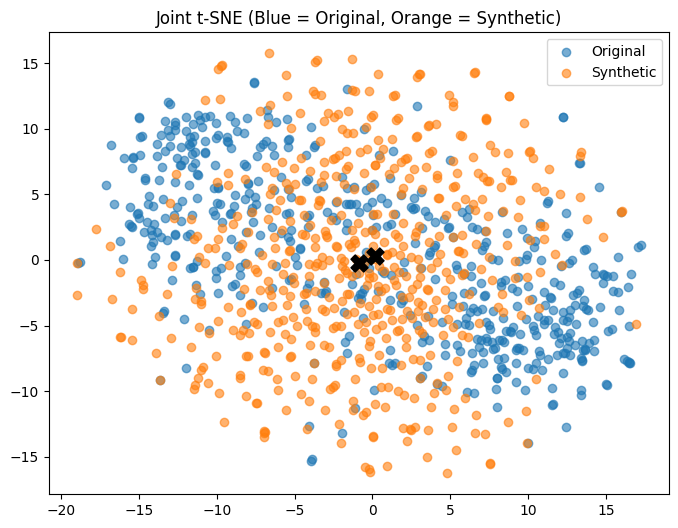

In [37]:
def centroide(original: pd.DataFrame,
              synthetic: pd.DataFrame,
              eps=0.5,
              min_samples=5):

    # Extract numerical & categorical columns
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)

    # One-hot encode categorical features
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))

    # Scale numerical features
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)

    # Combine numerical and categorical features
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)   # 0 = Original
    labels_syn  = np.ones(len(X_syn),  dtype=int)    # 1 = Synthetic

    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])

    # Color mapping: 0 -> Blue, 1 -> Orange
    color_map = {0: '#1f77b4', 1: '#ff7f0e'}

    # t-SNE transformation
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)

    # Compute centroids for each class (Original/Synthetic)
    centroids = []
    for label in np.unique(labels):
        points = tsne_joint[labels == label]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Plot
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        idx = labels == label
        plt.scatter(tsne_joint[idx, 0], tsne_joint[idx, 1],
                    c=color_map[label],
                    label="Original" if label == 0 else "Synthetic",
                    alpha=0.6)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                c='black', marker='X', s=150)  # Centroids in black
    plt.title('Joint t-SNE (Blue = Original, Orange = Synthetic)')
    plt.legend()
    plt.show()


# Call function with real and synthetic data
centroide(df_real, df_syn)


### K-Means Clustering
applies K-Means clustering on PCA- and t-SNE-transformed real and synthetic data, visualizes the resulting clusters side-by-side, and calculates Silhouette Scores to evaluate and compare the quality of clustering in both datasets.

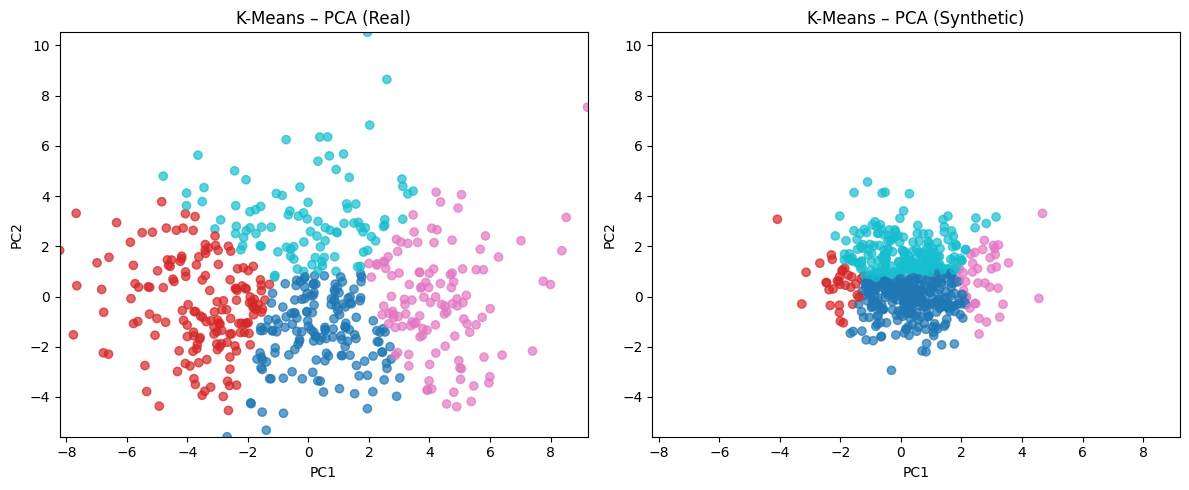

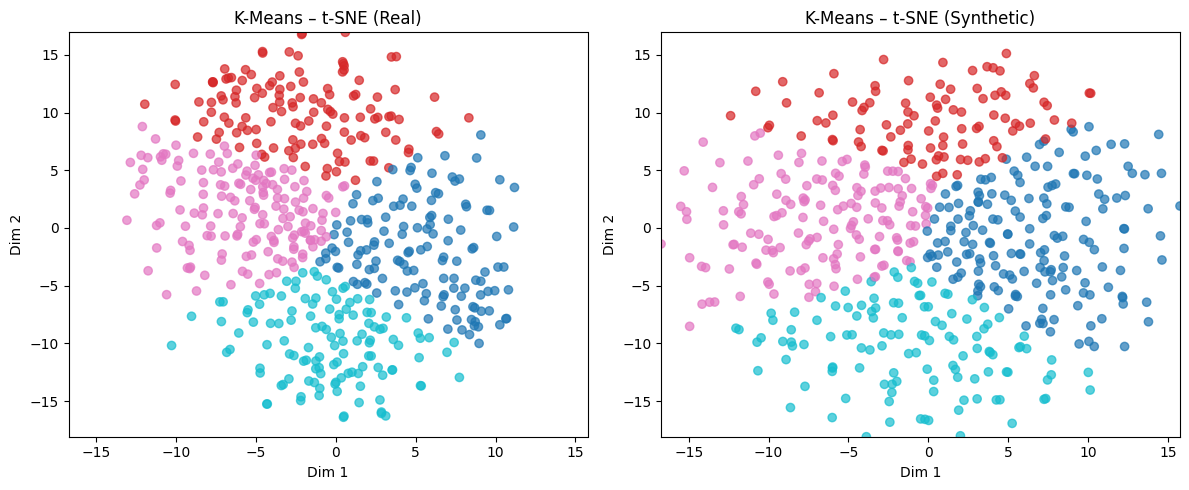

Silhouette Score (PCA – Real):         0.3254785401392916
Silhouette Score (PCA – Synthetic):    0.241655947780497
Silhouette Score (t-SNE – Real):       0.36866793036460876
Silhouette Score (t-SNE – Synthetic):  0.32929378747940063


In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Number of clusters
n_clusters = 4

# --- PCA Clustering ---
kmeans_pca = KMeans(n_clusters=n_clusters, random_state=42)
clusters_real_pca = kmeans_pca.fit_predict(real_pca)
clusters_syn_pca = kmeans_pca.predict(syn_pca)

# Axis limits (PCA)
x_min_pca = min(real_pca[:, 0].min(), syn_pca[:, 0].min())
x_max_pca = max(real_pca[:, 0].max(), syn_pca[:, 0].max())
y_min_pca = min(real_pca[:, 1].min(), syn_pca[:, 1].min())
y_max_pca = max(real_pca[:, 1].max(), syn_pca[:, 1].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_pca[:, 0], real_pca[:, 1], c=clusters_real_pca, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – PCA (Real)")
axes[0].set_xlim(x_min_pca, x_max_pca)
axes[0].set_ylim(y_min_pca, y_max_pca)

axes[1].scatter(syn_pca[:, 0], syn_pca[:, 1], c=clusters_syn_pca, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – PCA (Synthetic)")
axes[1].set_xlim(x_min_pca, x_max_pca)
axes[1].set_ylim(y_min_pca, y_max_pca)

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


# --- t-SNE Clustering ---
kmeans_tsne = KMeans(n_clusters=n_clusters, random_state=42)
clusters_real_tsne = kmeans_tsne.fit_predict(real_tsne)
clusters_syn_tsne = kmeans_tsne.predict(syn_tsne)

x_min_tsne = min(real_tsne[:, 0].min(), syn_tsne[:, 0].min())
x_max_tsne = max(real_tsne[:, 0].max(), syn_tsne[:, 0].max())
y_min_tsne = min(real_tsne[:, 1].min(), syn_tsne[:, 1].min())
y_max_tsne = max(real_tsne[:, 1].max(), syn_tsne[:, 1].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_tsne[:, 0], real_tsne[:, 1], c=clusters_real_tsne, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – t-SNE (Real)")
axes[0].set_xlim(x_min_tsne, x_max_tsne)
axes[0].set_ylim(y_min_tsne, y_max_tsne)

axes[1].scatter(syn_tsne[:, 0], syn_tsne[:, 1], c=clusters_syn_tsne, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – t-SNE (Synthetic)")
axes[1].set_xlim(x_min_tsne, x_max_tsne)
axes[1].set_ylim(y_min_tsne, y_max_tsne)

for ax in axes:
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()


# --- Optional: Evaluate clustering quality using Silhouette Score ---
print("Silhouette Score (PCA – Real):        ", silhouette_score(real_pca, clusters_real_pca))
print("Silhouette Score (PCA – Synthetic):   ", silhouette_score(syn_pca, clusters_syn_pca))
print("Silhouette Score (t-SNE – Real):      ", silhouette_score(real_tsne, clusters_real_tsne))
print("Silhouette Score (t-SNE – Synthetic): ", silhouette_score(syn_tsne, clusters_syn_tsne))


### Agglomerative Clustering
reduces real and synthetic datasets into two dimensions using t-SNE, applies agglomerative clustering to the combined data, and visualizes the cluster structure to assess structural consistency between the datasets.

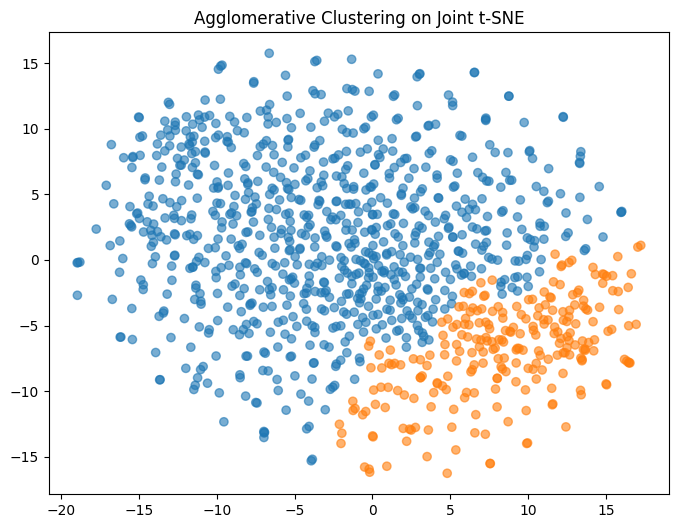

In [39]:
def visualize_structural_consistency(original: pd.DataFrame,
                                     synthetic: pd.DataFrame,
                                     eps=0.5,
                                     min_samples=5):
    # Identify shared numeric and categorical columns
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)

    # One-hot encode categorical features if any
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))

    # Standardize numeric features
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)

    # Combine numeric and categorical features
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)   # Label 0 = real
    labels_syn  = np.ones(len(X_syn),  dtype=int)     # Label 1 = synthetic

    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])

    color_map = {0: '#1f77b4', 1: '#ff7f0e'}  # Blue for real, orange for synthetic

    # t-SNE dimensionality reduction
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)

    # Agglomerative clustering on reduced data
    agg_cluster = AgglomerativeClustering(n_clusters=2).fit(tsne_joint)
    cluster_labels = agg_cluster.labels_

    # Calculate centroids for each cluster
    centroids = []
    for label in np.unique(cluster_labels):
        points = tsne_joint[cluster_labels == label]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_joint[:, 0], tsne_joint[:, 1],
                c=[color_map[label] if label in color_map else 'gray' for label in cluster_labels],
                alpha=0.6)
    plt.title("Agglomerative Clustering on Joint t-SNE")
    plt.show()

# Call the function with real and synthetic datasets
visualize_structural_consistency(df_real, df_syn)
